# FIGURES — Publication-Quality Figures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats
from pathlib import Path

# ── Paths ──────────────────────────────────────────────
DATA_DIR = Path("../data")
FIG_DIR  = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

# ── Load data ──────────────────────────────────────────
df_success = pd.read_csv(DATA_DIR / "cohort_success.csv")
df_failure = pd.read_csv(DATA_DIR / "cohort_failure.csv")
df_all     = pd.read_csv(DATA_DIR / "cohort_clustered.csv")

print(f"Success: {len(df_success):,}  |  Failure: {len(df_failure):,}  |  All: {len(df_all):,}")
print(f"Clusters: {df_all['cluster_label'].value_counts().to_dict()}")

# ── Column definitions ─────────────────────────────────
PACE_COLS = [
    'pace_05k', 'pace_510k', 'pace_1015k', 'pace_1520k',
    'pace_2025k', 'pace_2530k', 'pace_3035k', 'pace_3540k', 'pace_40End'
]
SEGMENT_LABELS = ['0-5', '5-10', '10-15', '15-20', '20-25',
                  '25-30', '30-35', '35-40', '40-42.2']

# ── Color palette ──────────────────────────────────────
C_SUCCESS = '#4C72B0'
C_FAILURE = '#C44E52'
C_REF     = '#55A868'

# ── rcParams ───────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.dpi': 100,
})

# ── Helper: save figure as TIFF 600 DPI LZW ───────────
def save_fig(fig, name: str) -> None:
    """Save figure as publication-quality TIFF."""
    path = FIG_DIR / f"{name}.tiff"
    fig.savefig(
        path, dpi=600, format='tiff',
        pil_kwargs={'compression': 'tiff_lzw'},
        bbox_inches='tight',
    )
    size_mb = path.stat().st_size / 1e6
    print(f"Saved: {path}  ({size_mb:.1f} MB)")

print("\nSetup complete.")

Success: 7,710  |  Failure: 1,875  |  All: 9,585
Clusters: {'Positive Split / Fade': 7127, 'Metabolic Crash': 2458}

Setup complete.


## Figure 1 — Pacing Profiles by Cluster

Saved: ../figures/Figure_1_Pacing_Profiles.tiff  (1.3 MB)


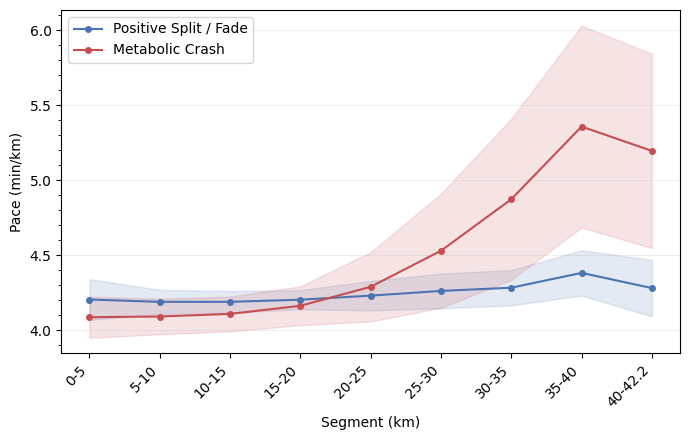

In [2]:
# Figure 1 — Pacing Profiles by Cluster (mean ± SD bands)
cluster_colors = {
    'Positive Split / Fade': C_SUCCESS,
    'Metabolic Crash': C_FAILURE,
}

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(SEGMENT_LABELS))

for label, color in cluster_colors.items():
    subset = df_all[df_all['cluster_label'] == label][PACE_COLS]
    mean = subset.mean()
    sd   = subset.std()
    ax.plot(x, mean, marker='o', markersize=4, color=color, label=label, linewidth=1.5)
    ax.fill_between(x, mean - sd, mean + sd, color=color, alpha=0.15)

ax.set_xticks(x)
ax.set_xticklabels(SEGMENT_LABELS, rotation=45, ha='right')
ax.set_xlabel('Segment (km)')
ax.set_ylabel('Pace (min/km)')
ax.legend(frameon=True, edgecolor='0.8')
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
fig.tight_layout()

save_fig(fig, 'Figure_1_Pacing_Profiles')
plt.show()

## Figure 2 — Cluster Distribution by Outcome

Saved: ../figures/Figure_2_Cluster_Outcome.tiff  (0.7 MB)


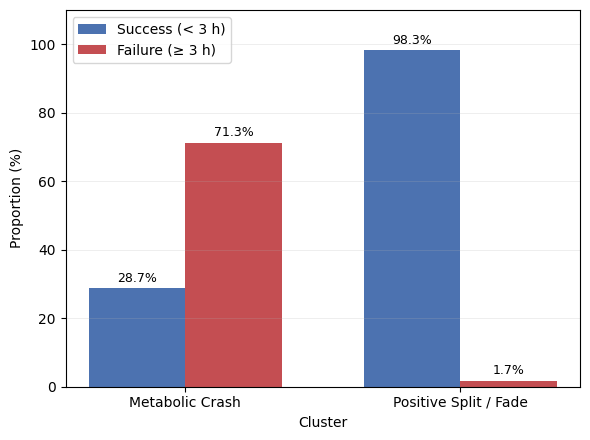

In [3]:
# Figure 2 — Cluster Distribution by Outcome (grouped bar chart)
ct = pd.crosstab(df_all['cluster_label'], df_all['outcome'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

labels = ct_pct.index.tolist()
success_pct = ct_pct['Success'].values
failure_pct = ct_pct['Failure'].values

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4.5))
bars_s = ax.bar(x - width/2, success_pct, width, color=C_SUCCESS, label='Success (< 3 h)')
bars_f = ax.bar(x + width/2, failure_pct, width, color=C_FAILURE, label='Failure (≥ 3 h)')

# Annotate bars
for bar in bars_s:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars_f:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Proportion (%)')
ax.set_xlabel('Cluster')
ax.set_ylim(0, 110)
ax.legend(frameon=True, edgecolor='0.8')
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
fig.tight_layout()

save_fig(fig, 'Figure_2_Cluster_Outcome')
plt.show()

## Figure 3 — Pacing Variability (CV) by Outcome

Mann-Whitney U = 511,572, p < 0.001


Saved: ../figures/Figure_3_CV_by_Outcome.tiff  (0.5 MB)


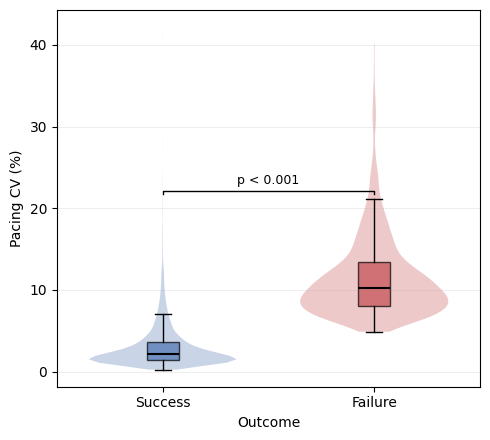

In [4]:
# Figure 3 — Pacing Variability (CV) by Outcome (violin + box + strip)
fig, ax = plt.subplots(figsize=(5, 4.5))

groups = ['Success', 'Failure']
colors = [C_SUCCESS, C_FAILURE]
data   = [df_success['pacing_cv'].dropna(), df_failure['pacing_cv'].dropna()]

# Violin plot
parts = ax.violinplot(data, positions=[0, 1], showextrema=False, widths=0.7)
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.3)

# Box plot overlay
bp = ax.boxplot(data, positions=[0, 1], widths=0.15, patch_artist=True,
                showfliers=False, zorder=3,
                medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Mann-Whitney U test
u_stat, p_val = stats.mannwhitneyu(data[0], data[1], alternative='two-sided')
y_max = max(data[0].quantile(0.95), data[1].quantile(0.95))
bracket_y = y_max * 1.05
ax.plot([0, 0, 1, 1], [bracket_y * 0.98, bracket_y, bracket_y, bracket_y * 0.98],
        color='black', linewidth=1)
p_text = f'p < 0.001' if p_val < 0.001 else f'p = {p_val:.3f}'
ax.text(0.5, bracket_y * 1.02, p_text, ha='center', va='bottom', fontsize=9)

ax.set_xticks([0, 1])
ax.set_xticklabels(groups)
ax.set_ylabel('Pacing CV (%)')
ax.set_xlabel('Outcome')
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
fig.tight_layout()

print(f"Mann-Whitney U = {u_stat:,.0f}, {p_text}")
save_fig(fig, 'Figure_3_CV_by_Outcome')
plt.show()

## Figure 4 — Start vs Finish Pace

Saved: ../figures/Figure_4_Start_vs_Finish.tiff  (1.3 MB)


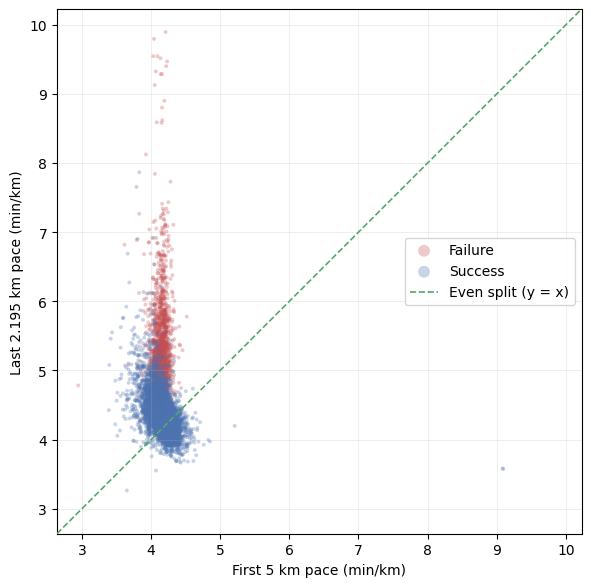

In [5]:
# Figure 4 — Start vs Finish Pace (scatter, colored by outcome)
fig, ax = plt.subplots(figsize=(6, 6))

# Plot Failure first (behind), then Success on top
ax.scatter(df_failure['pace_05k'], df_failure['pace_40End'],
           c=C_FAILURE, alpha=0.3, s=8, label='Failure', edgecolors='none', rasterized=True)
ax.scatter(df_success['pace_05k'], df_success['pace_40End'],
           c=C_SUCCESS, alpha=0.3, s=8, label='Success', edgecolors='none', rasterized=True)

# Diagonal y=x reference line (even split)
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, '--', color=C_REF, linewidth=1.2, label='Even split (y = x)', zorder=5)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel('First 5 km pace (min/km)')
ax.set_ylabel('Last 2.195 km pace (min/km)')
ax.set_aspect('equal')
ax.legend(frameon=True, edgecolor='0.8', markerscale=3)
ax.grid(alpha=0.3, linewidth=0.5)
fig.tight_layout()

save_fig(fig, 'Figure_4_Start_vs_Finish')
plt.show()

## Figure 5 — Segment-by-Segment Divergence

Bonferroni α = 0.0056  |  9/9 segments significant


Saved: ../figures/Figure_5_Segment_Divergence.tiff  (1.1 MB)


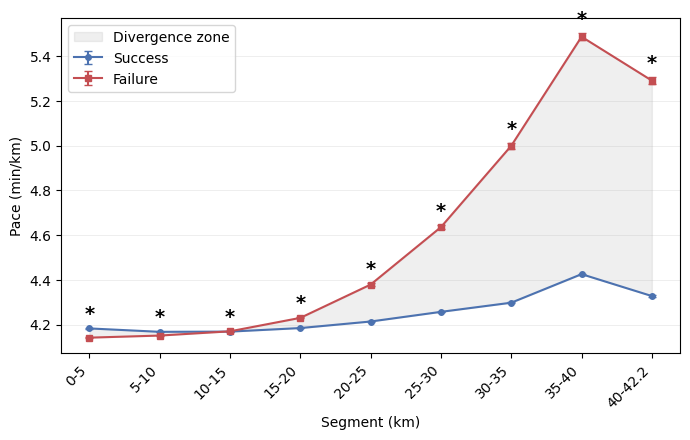

In [6]:
# Figure 5 — Segment-by-Segment Divergence (Success vs Failure, with significance)
x = np.arange(len(SEGMENT_LABELS))

mean_s = df_success[PACE_COLS].mean()
mean_f = df_failure[PACE_COLS].mean()
sd_s   = df_success[PACE_COLS].std()
sd_f   = df_failure[PACE_COLS].std()
n_s    = len(df_success)
n_f    = len(df_failure)
sem_s  = sd_s / np.sqrt(n_s)
sem_f  = sd_f / np.sqrt(n_f)

# Segment-by-segment Mann-Whitney with Bonferroni correction
n_tests = len(PACE_COLS)
alpha_bonf = 0.05 / n_tests
sig_markers = []
for col in PACE_COLS:
    _, p = stats.mannwhitneyu(
        df_success[col].dropna(), df_failure[col].dropna(), alternative='two-sided'
    )
    sig_markers.append(p < alpha_bonf)

fig, ax = plt.subplots(figsize=(7, 4.5))

# Lines with SEM error bars
ax.errorbar(x, mean_s, yerr=sem_s, marker='o', markersize=4, color=C_SUCCESS,
            label='Success', linewidth=1.5, capsize=3)
ax.errorbar(x, mean_f, yerr=sem_f, marker='s', markersize=4, color=C_FAILURE,
            label='Failure', linewidth=1.5, capsize=3)

# Shaded divergence region
ax.fill_between(x, mean_s, mean_f, color='grey', alpha=0.12, label='Divergence zone')

# Asterisks for significant segments (Bonferroni-corrected)
y_top = np.maximum(mean_s + sem_s, mean_f + sem_f)
for i, sig in enumerate(sig_markers):
    if sig:
        ax.text(i, y_top.iloc[i] + 0.02, '*', ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black')

ax.set_xticks(x)
ax.set_xticklabels(SEGMENT_LABELS, rotation=45, ha='right')
ax.set_xlabel('Segment (km)')
ax.set_ylabel('Pace (min/km)')
ax.legend(frameon=True, edgecolor='0.8')
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
fig.tight_layout()

n_sig = sum(sig_markers)
print(f"Bonferroni α = {alpha_bonf:.4f}  |  {n_sig}/{n_tests} segments significant")
save_fig(fig, 'Figure_5_Segment_Divergence')
plt.show()